### Loading a few Modules

we'll use pandas for manipulating the data and we'll use PandasTools in rdkit to draw molecules, if we want.

torch is pytorch, machine learning. We'll need some bits from that (could maybe remove a few imports though)

In [10]:
import pandas as pd
from rdkit.Chem import PandasTools
import pickle 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, SubsetRandomSampler
from sklearn.model_selection import train_test_split, KFold

### Loading Custom Modules

We load a few custom modules:
chemnet - handles chemical information, fingerprints etc
fionet  - this deals with file i/o opperations and data parsing etc
plotnet - this has our plotting tools in it
neurnet - this does the heavy lifting (via pytorch)
prednet - this allows us to use a trained network to make predictions on isolated things.

In [8]:
# import our own modules
from dielectric_ml import chemnet, fionet, plotnet, neurnet, prednet

### Data

We'll start by loading data. Here the dataset has >3000 molecules and most have dielectric anisotropy data.

we "clean" the data by dropping rows that are empty (df.dropna); we then use PandasTools inrdkit to turn those SMILES strings into actual molecule drawings.

### NOTE ###
In terms of getting MORE data for the dataset, seemingly it only goes back to about 1998. So we could:

* look in earlier patents.
* Look for other companies (chinese ones, Sumitomo, LG-chemical, RRE, DRA)
* Some companies that have been _exhaustively_ mined for data - JNC, Chisso, Samsung, QinetiQ, BaYi,
* Some companies that have been _partially_ mined for data - Merck, Daikan, Dainipon

Some possible areas to find more data:
* A lot of the "high frequency" materials (e.g. 5G/6G, microwave, THz) report optical data at GHz/THz frequencies but dielectric data at low frequency (e.g. 1 KHz) so its directly usable here
* We haven't really touched the academic literature, but the quality of the data is much poorer and is probably a leading source of error

In [19]:
file_path = 'new_DE_data.xlsx'
df= pd.read_excel(file_path)

clean_data = df.dropna(how="all", inplace=True)
PandasTools.RenderImagesInAllDataFrames(images=True)
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
pd.set_option('display.max_rows', 10)


### Examine Data

Just for interest, we can look at the data:

,Internal Name,Δε,Δn,y1,Phase Seq,smiles,ext. name,DOI,Unnamed: 8,ROMol
0,M_PK_1,9.7,0.075,160,K 66 N 94.1 I,CCCC0CCC(C1CCC(c2cc(F)c(F)c(F)c2)CC1)CC0,1,10.1002/ejoc.200800149,NaN,
1,M_PK_2,10.5,0.0668,145,K 44 N 105.3 I,CCCC0CCC(C1CCC(C(F)(F)Oc2cc(F)c(F)c(F)c2)CC1)CC0,2,10.1002/ejoc.200800149,NaN,
2,M_PK_3,17,0.068,201,C 74 N 51.2 I,CCCC0CCC(C1COC(c2cc(F)c(F)c(F)c2)OC1)CC0,3,10.1002/ejoc.200800149,NaN,
3,M_PK_4,25.2,0.1579,96,C 48 I,CCCc0ccc(c1cc(F)c(C(F)(F)Oc2cc(F)c(F)c(F)c2)c(...,4,10.1002/ejoc.200800149,NaN,
4,M_PK_5,15,0.0744,136,C 74 I,CCCC0COC(C1CCC(c2cc(F)c(F)c(F)c2)CC1)CC0,13,10.1002/ejoc.200800149,NaN,
...,...,...,...,...,...,...,...,...,...,...
3332,YF_ZS_7,-13.2,0.117,NaN,NaN,CCCc0c(F)c(F)c(c1c(F)c(F)c(CCCCC)cc1)cc0,x1,CN108517216A,NaN,
3333,YF_ZS_8,-14.5,0.152,NaN,NaN,CCCc9ccc(c0c(F)c(F)c(c1c(F)c(F)c(CCCCC)cc1)cc0...,x2,CN108517216A,NaN,
3334,X_JL_1,-9.37,0.178,204.7,K 119.2 I,CCOc1c(F)c2Oc3c(F)c(OCC4OCCCC4)ccc3c2cc1,1,CN114262323A,NaN,
3335,X_JL_2,NaN,NaN,NaN,K 93.8 I,CCCCOc1c(F)c2Oc3c(F)c(OCC4OCCCC4)ccc3c2cc1,2,CN114262323A,NaN,

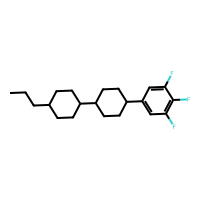
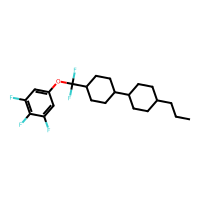
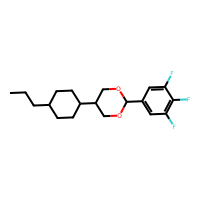
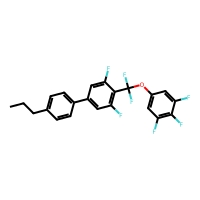
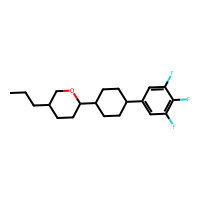
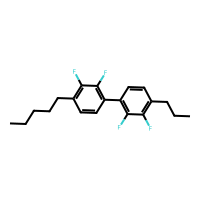
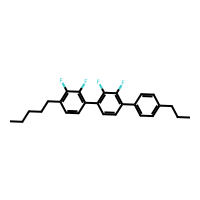
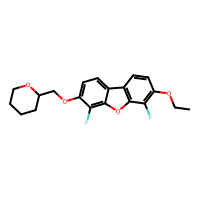
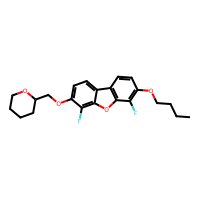
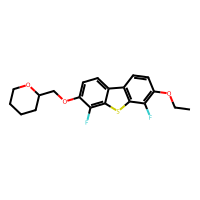

In [22]:
df

## Legacy code
In the past we would seperately generate conformers and then fingerprints. 

but chemnet.get_fingerprints_new actually does it all inside the same function, so we don't have to bother with that. 

I'll leave the code here, commented out, but I don't think the generate_low_energy_conformers() even exists anymore
Old comment was this, below:

### Generate Conformers and Fingerprints

We'll use chemnet to generate low energy conformers (using the ETKDGv3 method in rdkit) and then generate fingerprints. The conformer generation is pretty fast, but you are doing it for a thousand molecules so a little patience is needed. 

You can turn off the optimisation step (optimize = Bool) if you want a little speedup; this doesn't stop the "unrecognized atom type" errors.

If the atom type (e.g. S in SF5) isn't known to the conformer generator, then these get discarded. So its worth considering if you actually want conformers or not (they make no difference unless use_3D = True)...

This is where we have to start making a couple of choices:
fp_size - this is the "bit size" of the fingerprint. Basically how many numbers are you using to represent the molecule? 512 seems like a good start...
use_3D  - do we want to use conformer information? This gives us additional fingerprint types we can use, but at the cost of time (and requiring conformer info).

In [5]:
#reload(chemnet) # get the current version
#
#pd.set_option('display.max_rows', 10)
#df2 = df.iloc[:10].copy()
#
#chemnet.generate_low_energy_conformers(df2, smiles_column='smiles', optimize = False)
#
#fps2 = chemnet.get_fingerprints(df2, 
#                               smiles_column='smiles',
#                               conformer_column='min_e_conf',
#                               n_jobs=-1,
#                               fp_size=1024, 
#                               use_3D=True)

### get_fingerprints_new()

This is the new fingerprint generating wrapper function. 

Sometimes on my PC the kernel just dies when I run this.

You can reload the fingerprints from the pickle if you like.

In [ ]:
fps = chemnet.get_fingerprints_new(df, 
                                smiles_column = 'smiles', 
                                n_jobs=1,
                               fp_size=1024, 
                               use_3D=True)

In [ ]:
# optional; just list all the keys we have in our fingerprint list
for i, key in enumerate(fps.keys()): print(f"{i} = {key}")

In [16]:
# load fingerprints from pickle
import pickle

with open('new_de_fps.pkl', 'rb') as f:
    fps = pickle.load(f)

### Network Training

You made it this far. Here, we are going to train the neural network itself. 

First up we are setting the layers_config; this is saying what "topology" the network has. So here, the first thing in our network is a "nn.linear" which has an output size of "4"; this is just a linear transform of the incoming (fingerprint + birefringence) data https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html like this: <br><br>$y = xA^t+b$<br><br> so not that exciting really. Other layers of note are ReLU ($ReLU(x) = (x)^+=max(0,x)$); which returns its input if its positive or gives zero if not; dropout, which sort of adjusts the training to help the network learn (very very rough description there), and batchnorm1d which is normalising the data.

Notice those "nn.ReLU" layers are commented out with a #; I was seeing what happened if I removed them.

After that, you want to define a target; so our data we loaded is stored in "df" and it has a column called "Δn"; so we set

```target = df['Δn']``` 

and it will load it.

We next tell it which fingerprint type we want:

```fp_type = list(fps.keys())[-1]```

which is basically saying "use the last one in the list". You can type the name if you prefer, or use a different number (-1 means last one).

After that, final few parameters to be aware of:

Initial Length = 3337
mordred_fingerprint
Using default optim.Adam optimiser
Fold 1
Early stopping at epoch 64/500 (patience=25)


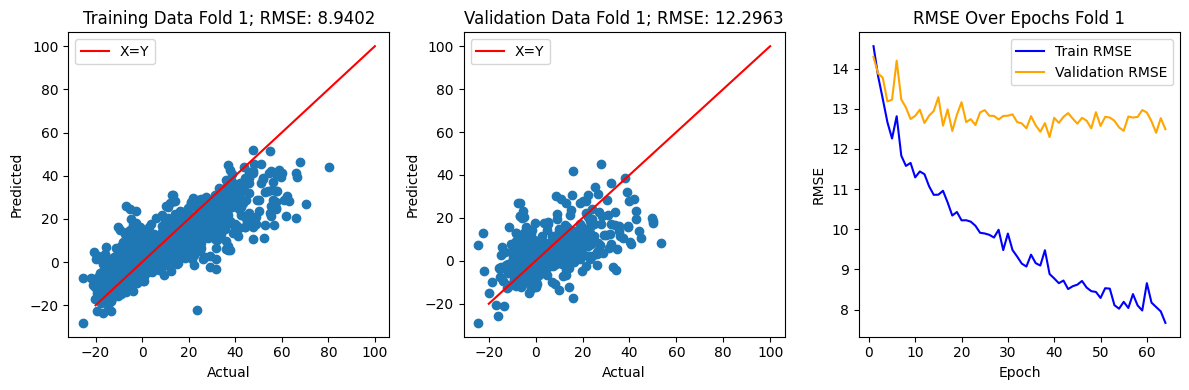

Fold 2
Early stopping at epoch 62/500 (patience=25)


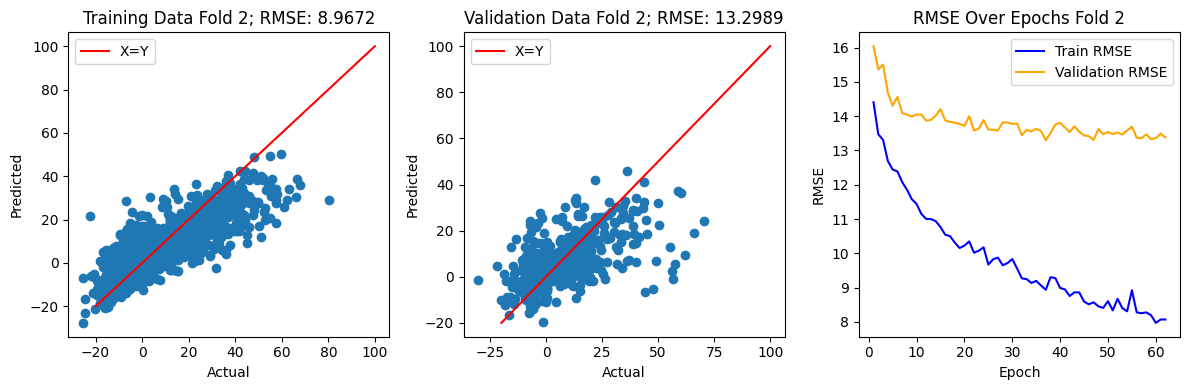

Fold 3
Early stopping at epoch 58/500 (patience=25)


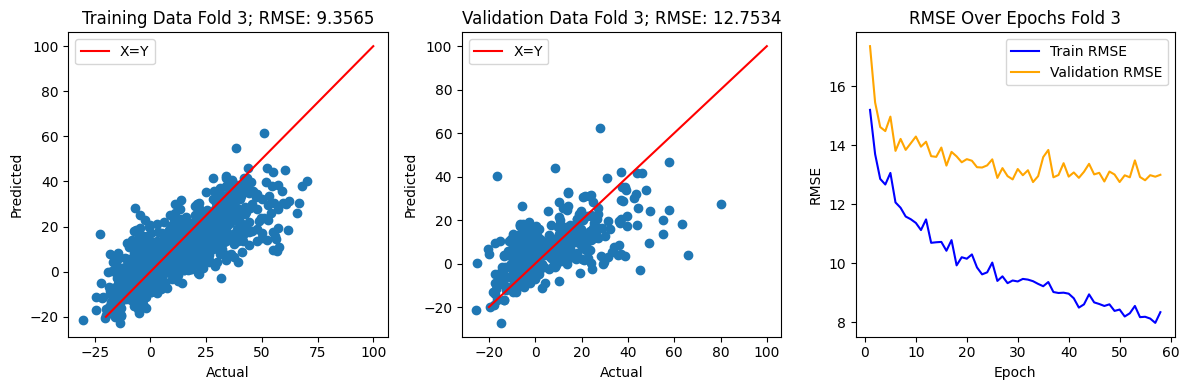

Fold 4
Early stopping at epoch 62/500 (patience=25)


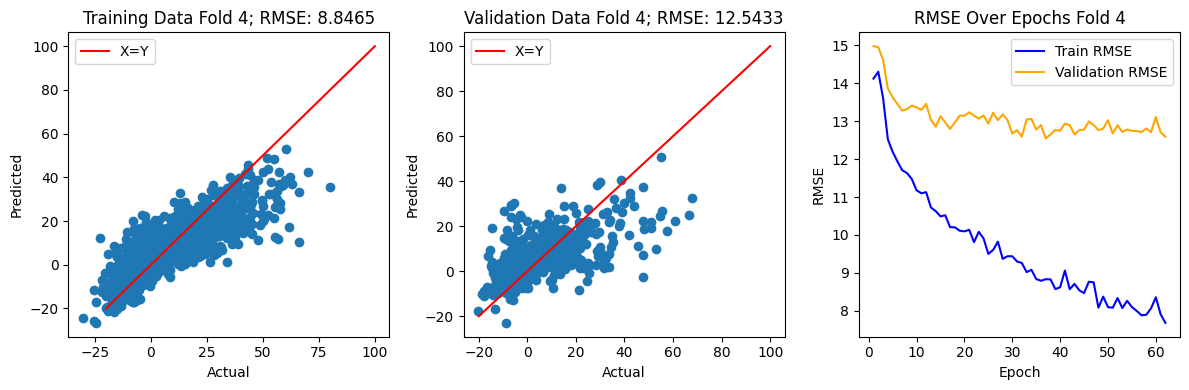

Fold 5
Early stopping at epoch 55/500 (patience=25)


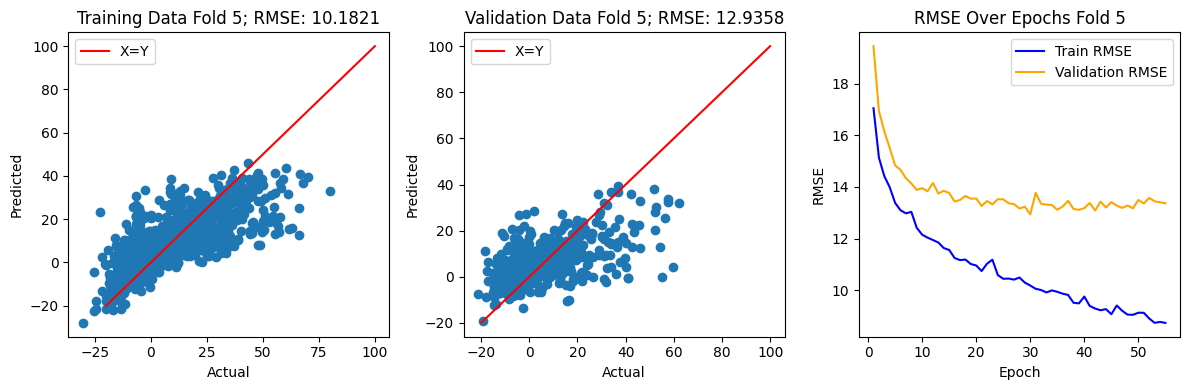

Validation RMSE across folds: mean=12.7656 ± 0.3819 (n=5)
Final holdout test set RMSE with best model (from fold 1) has RMSE: 13.5482


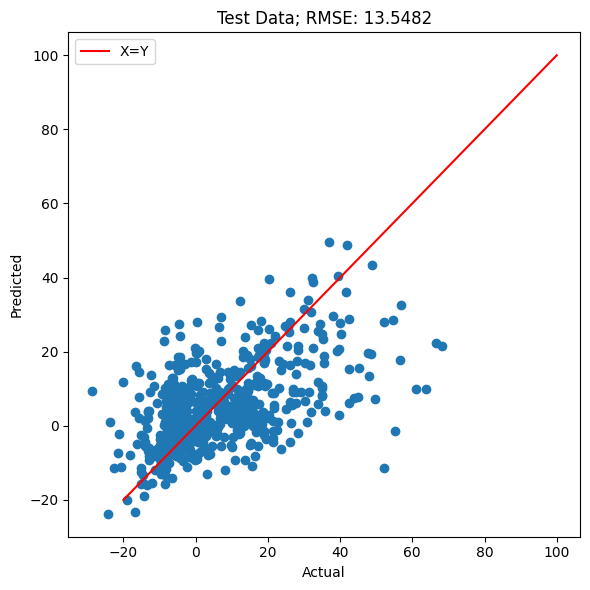

In [17]:
# set up our layer config
layers_config = [
    (nn.Linear, {'out_size': 32}),
    (nn.ReLU, {}),
    (nn.Dropout, {'p': 0.15}),
    (nn.Linear, {'out_size':16}),
    (nn.ReLU, {}),
]

target = df['Δε'] # if you wanted to train for dielectric anisotropy you would use this instead, for example.
#target = df['Δn']
print(f"Initial Length = {len(target)}")

# use the chemnet filter to remove null/None values from fprints and corresponding temperatures.
fp_type = list(fps.keys())[12] # fp[12] is the mordred fingerprint
#fp_type = 'ecfp_fingerprint'
print(fp_type)
fprints, target = chemnet.clean_fprints_targets(fps[fp_type], target)

# get model using neurnet.create_simple_model
model = neurnet.create_simple_model(input_data=fprints,
                            layer_config=layers_config,
                            output_size=1)

# train the model
best_model = neurnet.train_model_kfold(fprints, # fingerprints
                  target,           # target property
                  model,
                  criterion = None,
                  optimiser_class = None,
                  test_split_size = 0.2, # how to split the data for "training" and "validation"; if you run this, you'll see what I mean
                  num_epochs=500,        # how many "epochs" to train for. You make it a bigger number, it trains for longer, but takes longer
                  k=5,                   # how many different ways to split the data up for training (use 3 min, maybe 10 max, but 5 is probably perfect)
                  batch_size=64,
                  learn_rate=5e-4,       # how fast the model learns, more is not necesarily better!
                  weight_decay=1e-4,
                  patience=25,
                  style='scatter',limits=[-20,100]) # "style" controls the plotting style (scatter or hexbin); limits controls where the plot will be shown (min, max).

C:\Users\phyrma\AppData\Local\Temp\ipykernel_22148\3207766852.py:25: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  cs.collections[0].remove() # becasue the outer one bugs me


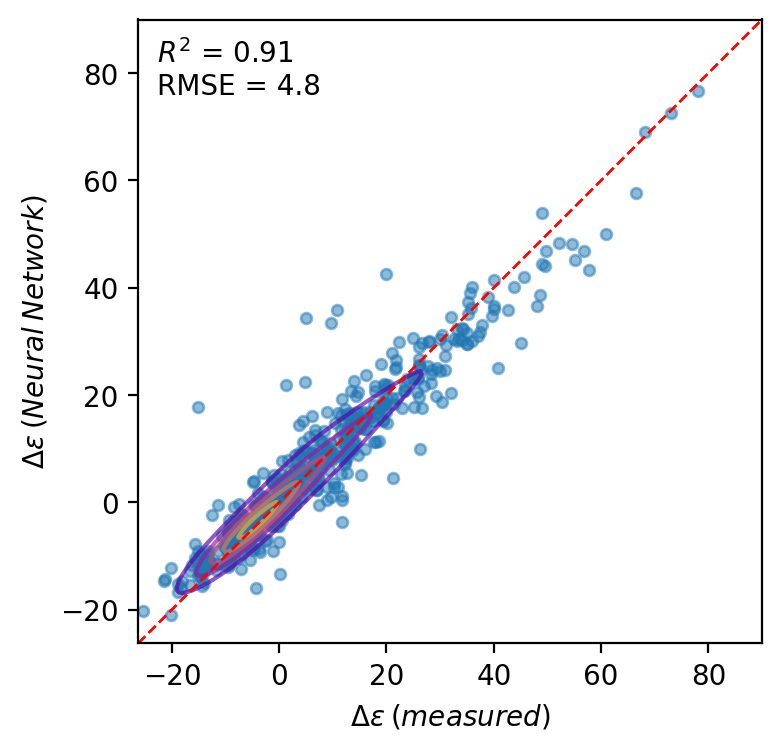

In [236]:
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import gaussian_kde


def density_panel(ax, x, y, title, xlabel, ylabel, minima, maxima=100, ngrid=200,
                  n_contours=6, scatter_n=5000):
    """
    Plot KDE density contours plus a light scatter overlay.
    scatter_n: max number of points to overlay (for speed/clarity).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    rmse = np.sqrt(mean_squared_error(x, y))
    r2   = r2_score(x, y)

    xi = np.linspace(minima, maxima, ngrid)
    yi = np.linspace(minima, maxima, ngrid)
    Xg, Yg = np.meshgrid(xi, yi)

    kde = gaussian_kde(np.vstack([x, y]))
    Zg = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)

    cs = ax.contour(Xg, Yg, Zg, levels=n_contours, cmap = 'plasma', alpha = 0.66)
    cs.collections[0].remove() # becasue the outer one bugs me
    
    if len(x) > scatter_n:
        idx = np.random.choice(len(x), size=scatter_n, replace=False)
        xs, ys = x[idx], y[idx]
    else:
        xs, ys = x, y

    ax.scatter(xs, ys, s=15, alpha=0.5)

    ax.plot([minima, maxima], [minima, maxima], 'r--', linewidth=1)

    ax.set_xlim(minima, maxima)
    ax.set_ylim(minima, maxima)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.text(
        0.03, 0.97,
        f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, linewidth=0)
    )

    return rmse, r2

x = best_model[9]
y = best_model[10]

fig, axes = plt.subplots(1, 1, figsize=(4, 4), dpi=200, sharex=True, sharey=True)

minima = np.nanmin([x, y]) - 1
maxima = 90

density_panel(
    axes, x, y,
    title="ML",
    xlabel=r"$\Delta\epsilon\:(measured)$",
    ylabel=r"$\Delta\epsilon\:(Neural \: Network)$",
    minima = minima, maxima = maxima
)
plt.tight_layout()
plt.show()


### Training on all the fingerprints

Just run the training inside a loop of keys in fps.keys() and store the mean RMSE and err of the holdout test set so we can see which is "best".

In [200]:
# or do it in a loop, and record the RMSE of the test set:
results_mean = {}
results_err  = {}

for key in fps.keys():
    layers_config = [
        (nn.Linear, {'out_size': 32}),
        (nn.ReLU, {}),
        (nn.Dropout, {'p': 0.15}),
        (nn.Linear, {'out_size':16}),
        (nn.ReLU, {}),
    ]
    
    target = df['Δε'] # if you wanted to train for dielectric anisotropy you would use this instead, for example.
    #target = df['Δn']
    print(f"Initial Length = {len(target)}")
    
    # use the chemnet filter to remove null/None values from fprints and corresponding temperatures.
    fp_type = key #
    print(fp_type)
    fprints, target = chemnet.clean_fprints_targets(fps[fp_type], target)
    
    # get model using neurnet.create_simple_model
    model = neurnet.create_simple_model(input_data=fprints,
                                layer_config=layers_config,
                                output_size=1)
    
    # train the model
    best_model = neurnet.train_model_kfold(fprints, # fingerprints
                      target,           # target property
                      model,
                      criterion = None,
                      optimiser_class = None,
                      test_split_size = 0.2, # how to split the data for "training" and "validation"; if you run this, you'll see what I mean
                      num_epochs=500,        # how many "epochs" to train for. You make it a bigger number, it trains for longer, but takes longer
                      k=5,                   # how many different ways to split the data up for training (use 3 min, maybe 10 max, but 5 is probably perfect)
                      batch_size=64,
                      learn_rate=5e-4,       # how fast the model learns, more is not necesarily better!
                      weight_decay=1e-4,
                      patience=50,
                      plot_output = False,
                      style='scatter',limits=[-20,100]) # "style" controls the plotting style (scatter or hexbin); limits controls where the plot will be shown (min, max).
    results_mean[key] = best_model[2]
    results_err[key] = best_model[7]

Initial Length = 3234
atom_pair_fingerprint
Using default optim.Adam optimiser
Fold 1
Epoch 100/500, Train RMSE: 2.1210, Val RMSE: 6.9679
Early stopping at epoch 166/500 (patience=50)
Fold 2
Epoch 100/500, Train RMSE: 2.0947, Val RMSE: 5.5299
Early stopping at epoch 164/500 (patience=50)
Fold 3
Epoch 100/500, Train RMSE: 1.8041, Val RMSE: 5.7482
Early stopping at epoch 172/500 (patience=50)
Fold 4
Epoch 100/500, Train RMSE: 2.2840, Val RMSE: 6.5930
Early stopping at epoch 145/500 (patience=50)
Fold 5
Epoch 100/500, Train RMSE: 1.9246, Val RMSE: 5.7229
Early stopping at epoch 142/500 (patience=50)
Validation RMSE across folds: mean=5.8410 ± 0.5483 (n=5)
Final holdout test set RMSE with best model (from fold 2) has RMSE: 6.0961
Initial Length = 3234
autocorr_fingerprint
Using default optim.Adam optimiser
Fold 1
Epoch 100/500, Train RMSE: 3.2708, Val RMSE: 5.8456
Early stopping at epoch 184/500 (patience=50)
Fold 2
Epoch 100/500, Train RMSE: 3.5653, Val RMSE: 5.0434
Early stopping at epoc

### Predicting using a model

Fairly sure this won't work because its old code and I haven't updated it to work with generate_fingerprints_new()

Idea is you just pass the model to use, and a bunch of smiles, and the fingerprint type and it will return what it expects for the property in question.

Probably would be good to automatically use the correct fingerprint type...

In [222]:
#prednet.predict_from_smiles(smiles = ["C=CC(=O)OCCCCOc1cc(C)c(C#Cc2ccc(C#Cc3c(C)cc(OCCCCOC(=O)C=C)cc3)cc2)cc1",
#                                      "C=CC(=O)OCCCCOc1cc(C)c(C#Cc2ccc(C#Cc3c(C)cc(OCCCCOC(=O)C=C)cc3)c4ccccc42)cc1",
#                                      "CCCCCc0ccc(c1ccc(C#N)cc1)cc0"], 
#                            
#                            fp_type = 'topo_tors_fingerprint', 
#                            model = best_model[0], 
#                            scaler_x = best_model[5], 
#                            scaler_y = best_model[6])

#### Comparing fingerprint type performance

Just make a nice bar plot to see which models are best. Sort it so biggest RMSE (Worst) is at the left.

In [ ]:

sorted_items = sorted(results_mean.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_items)

# errors in the same order
errs = np.array([results_err[l] for l in labels])
errs = np.sqrt(errs)   # REMOVE this line if results_err already stores std dev

colors = ["tab:red" if "3D" in label else "tab:blue" for label in labels]

labels_clean = tuple(
    l.replace('_3D', '').replace('_', ' ').replace('fingerprint', '')
    for l in labels
)

plt.figure(figsize=(8, 6), dpi=200)

plt.bar(
    range(len(values)),
    values,
    yerr=errs,
    capsize=3,
    color=colors,
    edgecolor='k',
    alpha=0.6
)

plt.xticks(range(len(labels)), labels_clean, rotation=90)
plt.ylabel("RMSE")
plt.xlabel("Fingerprint Type")

# these values were determined from the experimental dataset
rmse_am1 = 9.66
rmse_r2scan = 11.2

plt.axhline(rmse_am1, color="k", linestyle="--", linewidth=1.5, alpha=0.8)
plt.text(13, rmse_am1, 'AM1', fontsize=12, va='center', ha='center', backgroundcolor='w')

plt.axhline(rmse_r2scan, color="k", linestyle=":", linewidth=1.8, alpha=0.8)
plt.text(13, rmse_r2scan, 'r2scan-3c', fontsize=12, va='center', ha='center', backgroundcolor='w')

legend_elements = [
    Patch(facecolor="tab:blue", label="2D fingerprints"),
    Patch(facecolor="tab:red", label="3D (conformer-based) fingerprints"),
]

plt.legend(handles=legend_elements, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

In [241]:
# save the df to a pickle
df.to_pickle('gen_data_20260125_v1')

In [243]:
# save df table with conformer info
df.to_pickle('gen_data_20260125_v1')

# save fingerprint info
with open('fingerprint_dict_20260125_v1.pkl', 'wb') as f:
    pickle.dump(fps, f)

# write results info
with open('results_dict_20260125_v1.pkl', 'wb') as f:
    pickle.dump([results_mean, results_err],f)

# write model info
with open('best_model_dict_20260125_v1.pkl', 'wb') as f:
    pickle.dump(best_model,f)